# Electricity Forecasting Features

## 1. Temperature MAX temp BOM

In [193]:
#standard packages
import pandas as pd
import os 
import matplotlib.pyplot as plt
import numpy as np
import re
import seaborn as sns
from datetime import date

#modelling packages
import statsmodels as sm
import xgboost as xgb

In [194]:
#csv weather data from BOM -  Australian climate data Climate Data Online
#https://www.bom.gov.au/climate/data/

#get data folder path
data_folder = os.path.join(os.getcwd(), r'raw data - temperature major cities')
#get list of CSV names in folder
files = [s for s in os.listdir(data_folder) if s.endswith('.csv')]

In [195]:
# select range
start_date = date(1950, 1, 1)
end_date = date(2026, 1, 31)

#create df with full date range.
weather_daily = pd.DataFrame(pd.date_range(start=start_date, end=end_date), columns=['Date'])

In [196]:
# bring in seperate csvs and combine into a sigle source.
for i in files:
    data = pd.read_csv(os.path.join(data_folder,i))
    data['date'] = pd.to_datetime(data[['Year', 'Month', 'Day']])

    data = data[['date', 'Maximum temperature (Degree C)' ]]
    data = data.rename(columns={'Maximum temperature (Degree C)': i})
    weather_daily = weather_daily.merge(data,how='inner',left_on = 'Date', right_on = 'date' ).drop(columns=['date'])

In [197]:
weather_daily = weather_daily.rename(columns={'Date': 'date',
                        'IDCJAC0010_Adelaide Airport MO Jan 2026.csv':'Max Temp Adelaide',
                        'IDCJAC0010_Amberly QLD Jan 2026 - Near Brisbane.csv':'Max Temp Brisbane',
                        'IDCJAC0010_Burrinjuck Dam NSW Jan 2026 - Near Canberra.csv':'Max Temp Canberra',
                        'IDCJAC0010_Melbourne Airport Jan 2026.csv':'Max Temp Melbourne',
                        'IDCJAC0010_Perth Airport Jan 2026.csv':'Max Temp Perth',
                        'IDCJAC0010_Sydney Airport Jan 2026.csv': 'Max Temp Sydney'})

#weather_daily.loc[weather_daily['Max Temp Melbourne'].isna()]

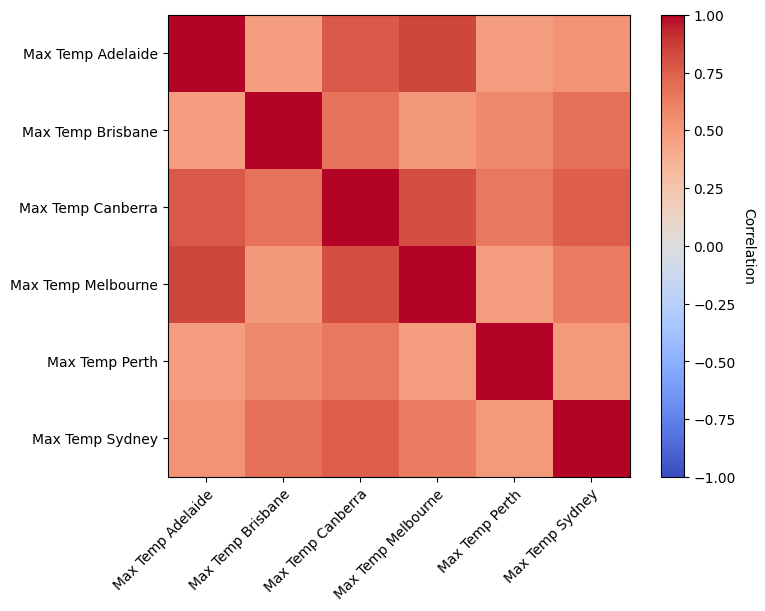

In [198]:
#is there much correlation between each cities max temps?
corr_matrix = weather_daily.drop(columns=['date']).corr()

#create plot
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel("Correlation", rotation=-90, va="bottom")
ax.set_xticks(np.arange(len(corr_matrix.columns)))
ax.set_yticks(np.arange(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns)
ax.set_yticklabels(corr_matrix.columns)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
plt.show()

#small correlations, for Adelaide and Melbourne there is much more, similar latitude and longditude, and by the ocean.

In [199]:
#select columns
weather_daily = weather_daily[['date','Max Temp Sydney', 'Max Temp Melbourne','Max Temp Brisbane']]

#weather_daily.dtypes

weather_daily= weather_daily.set_index('date')
weather_daily = weather_daily[['Max Temp Sydney', 'Max Temp Melbourne','Max Temp Brisbane']].resample('MS').mean()
weather_daily = weather_daily.reset_index()

#rename columns
weather_daily = weather_daily.rename(columns = {'Max Temp Sydney':'NSW',
                                                'Max Temp Melbourne':'VIC',
                                                'Max Temp Brisbane':'QLD'})
#short format
states = ['NSW','VIC','QLD']
avg_max_temp = pd.DataFrame(columns=['date','avgmax_temp','state'])

for i in states:
    temp_df = weather_daily[['date',i]]
    temp_df = temp_df.rename(columns = {i : 'avgmax_temp'})
    temp_df['state'] = i
    avg_max_temp = pd.concat([avg_max_temp ,temp_df])


In [200]:
#move to parquet
file_name = 'weather_daily.parquet'
data_folder = os.path.join(os.getcwd(), r'features')

path = os.path.join(data_folder,file_name)
avg_max_temp.to_parquet(path)

## 2. State Electricity

In [201]:
def process_state_data(file_name, state_name):
    #import data
    data_folder = os.path.join(os.getcwd(), r'raw data - state electricity')

    path = os.path.join(data_folder ,file_name)
    data = pd.read_csv(path)

    # standardise the column names
    data.columns = data.columns.str.lower().str.replace('  ', ' ').str.replace(r'[^\w\s]', '', regex=True).str.replace(' ', '_')
    data.columns = data.columns.str.replace('___', '_').str.replace('__', '_')   

    cols = ['date',
                'battery_charging_gwh',
                'pumps_gwh',
                'exports_gwh',
                'imports_gwh',
                'coal_gwh',
                'bioenergy_gwh',
                'distillate_gwh',
                'gas_gwh',
                'battery_discharging_gwh',
                'hydro_gwh',
                'wind_gwh',
                'solar_gwh',
                'temperature_mean_c',
                'volume_weighted_price_audmwh']
    
    #make sure the columns exist.
    cols = [item for item in cols if item in list(data.columns)]
    
    # select columns
    data = data[cols]

    # Convert date to datetime
    data['date'] = pd.to_datetime(data['date'], dayfirst=True, errors='coerce')
    data = data.dropna(subset=['date'])

    net_elc = ['battery_charging_gwh',
                'pumps_gwh',
                'exports_gwh',
                'imports_gwh',
                'coal_gwh',
                'bioenergy_gwh',
                'distillate_gwh',
                'gas_gwh',
                'battery_discharging_gwh',
                'hydro_gwh',
                'wind_gwh',
                'solar_gwh']
    
    #make sure the columns exist.
    net_elc = [item for item in net_elc if item in list(data.columns)]
    
    # calculate net elec
    data['net_electricity_gwh'] = data[net_elc].sum(axis=1)

    # other columns
    temp_col = 'temperature_mean_c'
    price_col = 'volume_weighted_price_audmwh'

    # Calculate monthly mean diversion for temperature, since temperature is likely to be non-monotonic correlated with electricity usage.
    data['month'] = data['date'].dt.month
    monthly_mean_temp = data.groupby('month')[temp_col].transform('mean')
    data['temp_diversion_from_month_mean'] = data[temp_col] - monthly_mean_temp

    # Prepare result dataframe
    result = data[['date', 'net_electricity_gwh', temp_col, price_col, 'temp_diversion_from_month_mean']].copy()
    result['state'] = state_name

    return result


In [202]:
#loop through and combine output
files = {
    '19981201 Queensland.csv': 'QLD',
    '19981201 Victoria.csv': 'VIC',
    '19981201 New South Wales.csv': 'NSW'
}

#list of dfs
all_data = []
for file_name, state_name in files.items():
    all_data.append(process_state_data(file_name, state_name))
    print(file_name)

#combine dfs
combined_df = pd.concat(all_data, ignore_index=True)

#sort
combined_df = combined_df.sort_values(['date', 'state']).reset_index(drop=True)

#move to parquet
file_name = 'combined_open_elec_data.parquet'
data_folder = os.path.join(os.getcwd(), r'features')

path = os.path.join(data_folder,file_name)
combined_df.to_parquet(path)

#combined_df.loc[(combined_df['state'] == 'VIC')&(combined_df['net_electricity_gwh'] != 0.0)].head(30)

19981201 Queensland.csv
19981201 Victoria.csv
19981201 New South Wales.csv


## 3. Population

In [203]:
#import ABS population stats
data_folder = os.path.join(os.getcwd(), r'raw data - state population')
file_name = 'interpolated_population_qld_nsw_vic.csv'

path = os.path.join(data_folder ,file_name)
data = pd.read_csv(path)

In [204]:
#round interpolated population data (used linear interpolation)
#These are so consistent upwards trend that x(t) time variable will be similar in effectiveness.
#cols = list(data.columns)
cols = ['NSW', 'VIC', 'QLD']

for i in cols:
    data[i] = data[i].round(1)

data = data.rename(columns = {'Date' : 'date'})

#short format
states = ['NSW','VIC','QLD']
pop = pd.DataFrame(columns=['date','population','state'])

for i in cols:
    temp_df = data[['date',i]]
    temp_df = temp_df.rename(columns = {i : 'population'})
    temp_df['state'] = i
    pop = pd.concat([pop ,temp_df])

In [205]:
#move to parquet
file_name = 'population_data.parquet'
data_folder = os.path.join(os.getcwd(), r'features')

path = os.path.join(data_folder,file_name)
pop.to_parquet(path)

## 4.Solar Exposure

In [206]:
#import solar exposure stats from open electricity
data_folder = os.path.join(os.getcwd(), r'raw data - solar exposure')

#get list of CSV names in folder
file = [s for s in os.listdir(data_folder) if s.endswith('.csv')]

file_dictionary = {'IDCJAC0003_040913_Brisbane Monthly Jan 2016.csv': 'QLD',
                    'IDCJAC0003_066024_Sydney Airport Monthly Jan 2016.csv':'NSW',
                    'IDCJAC0003_086282_Melbourne Airport Monthly Jan 2016.csv':'VIC'}

combined_data = pd.DataFrame(columns=['date','state','solar_exposure'])

In [207]:

for i in file:
    
    file_name = i

    path = os.path.join(data_folder ,file_name)
    data = pd.read_csv(path)

    # standardise the column names
    data.columns = data.columns.str.lower().str.replace('  ', ' ').str.replace(r'[^\w\s]', '', regex=True).str.replace(' ', '_')
    data.columns = data.columns.str.replace('___', '_').str.replace('__', '_')   

    #get date column and state columns
    data = data.rename(columns = {'monthly_mean_daily_global_solar_exposure_mjmm':'solar_exposure'})
    data['day'] = 1

    data['date'] = pd.to_datetime(data[['year','month','day']], dayfirst=True, errors='coerce')

    data['state'] = file_dictionary[i]

    #final data
    data = data[['date','state','solar_exposure']]

    #append data on top of one another
    combined_data = pd.concat([combined_data, data], axis=0)



In [208]:
#output data to parquet
data_folder = os.path.join(os.getcwd(), r'features')
file_name = r'solar_exposure.parquet'

path = os.path.join(data_folder,file_name)
combined_data.to_parquet(path)